<a href="https://colab.research.google.com/github/Zainab-Binte-Khalid/urdu-ocr-codesaviours-si26-zainab/blob/main/SI26_Week02_Zainab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 — Urdu OCR Project
This notebook preprocesses the Week 1 image dataset (grayscale, contrast enhancement,
denoising, adaptive binarization) across four categories — synthetic, handwritten,
newspaper, and signboard — and tests Tesseract OCR's baseline performance on Urdu text
to identify why a custom model is needed.

Install libraries

In [ ]:
!pip install opencv-python-headless pillow pytesseract -q
!apt-get install -y tesseract-ocr tesseract-ocr-urd -q

import cv2
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
import pytesseract
import shutil
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

print('Libraries loaded successfully!')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 0s (23.7 MB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Mounted at /content/drive
Libraries loaded successfully!


Restore Week 1 dataset

In [ ]:
shutil.unpack_archive('/content/drive/MyDrive/Urdu_OCR/urdu_ocr_dataset.zip', 'urdu_ocr_dataset')

df = pd.read_csv('urdu_ocr_dataset/labels.csv')
print('Dataset restored:', df.shape)
print(df['source'].value_counts())

Dataset restored: (134, 3)
source
handwritten    78
synthetic      24
newspaper      17
signboard      15
Name: count, dtype: int64


Preprocessing functions

In [ ]:
def preprocess_handwritten(image_path, save_path):
    """Handwritten-specific: darkens faint strokes, preserves nuqtay, crops blank space."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(gray)
    denoised = cv2.fastNlMeansDenoising(contrast_enhanced, h=3)
    binary = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    kernel = np.ones((2, 2), np.uint8)
    darkened = cv2.erode(binary, kernel, iterations=1)
    inverted = 255 - darkened
    coords = cv2.findNonZero(inverted)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        pad = 15
        x = max(0, x - pad); y = max(0, y - pad)
        w = min(darkened.shape[1] - x, w + 2*pad)
        h = min(darkened.shape[0] - y, h + 2*pad)
        cropped = darkened[y:y+h, x:x+w]
    else:
        cropped = darkened
    target_w = 512
    h, w = cropped.shape
    scale = target_w / w
    new_h = int(h * scale)
    resized = cv2.resize(cropped, (target_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    cv2.imwrite(save_path, resized)
    return resized


def preprocess_standard(image_path, save_path):
    """Standard pipeline for synthetic, newspaper, and signboard images."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(gray)
    target_w = 512
    max_h = 256
    h, w = contrast_enhanced.shape
    scale = target_w / w
    new_h = min(int(h * scale), max_h)
    resized = cv2.resize(contrast_enhanced, (target_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    canvas = np.full((max_h, target_w), 255, dtype=np.uint8)
    canvas[:new_h, :] = resized
    denoised = cv2.fastNlMeansDenoising(canvas, h=5)
    binary = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 4)
    cv2.imwrite(save_path, binary)
    return binary

print('Preprocessing functions ready!')

Preprocessing functions ready!


In [ ]:
os.makedirs('urdu_ocr_dataset/processed', exist_ok=True)
processed_count = 0

for category in ['synthetic', 'newspaper', 'handwritten']:
    files = glob.glob(f'urdu_ocr_dataset/images/{category}/*')
    for img_path in files:
        filename = os.path.basename(img_path)
        save_path = f'urdu_ocr_dataset/processed/{filename}'
        result = preprocess_handwritten(img_path, save_path) if category == 'handwritten' else preprocess_standard(img_path, save_path)
        if result is not None:
            processed_count += 1

# Signboards use the manually cropped versions (removes excess background clutter)
signboard_files = glob.glob('/content/drive/MyDrive/archive/signboards_cropped/*')
for img_path in signboard_files:
    filename = os.path.basename(img_path)
    save_path = f'urdu_ocr_dataset/processed/{filename}'
    result = preprocess_standard(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f'Done! Processed {processed_count} images')

Done! Processed 134 images


Organize into folders

In [ ]:
import re

processed_base = 'urdu_ocr_dataset/processed'
organized_base = 'urdu_ocr_dataset/processed_organized'

categories = ['synthetic', 'handwritten', 'newspaper', 'signboard']

if os.path.exists(organized_base):
    shutil.rmtree(organized_base)
for cat in categories:
    os.makedirs(f'{organized_base}/{cat}', exist_ok=True)

all_files = os.listdir(processed_base)
counts = {cat: 0 for cat in categories}

def extract_number(filename):
    match = re.search(r'(\d+)', filename)
    return int(match.group(1)) if match else 0

for cat in categories:
    cat_files = [f for f in all_files if f.startswith(cat)]
    cat_files_sorted = sorted(cat_files, key=extract_number)
    total = len(cat_files_sorted)
    pad_width = len(str(total))

    for i, fname in enumerate(cat_files_sorted, 1):
        ext = os.path.splitext(fname)[1]
        new_name = f'{cat}_{str(i).zfill(pad_width)}{ext}'
        shutil.copy(os.path.join(processed_base, fname), os.path.join(organized_base, cat, new_name))
        counts[cat] += 1

print('Final organized counts:')
for cat, count in counts.items():
    print(f'  {cat}: {count}')
print(f'Total: {sum(counts.values())}')

Final organized counts:
  synthetic: 24
  handwritten: 78
  newspaper: 17
  signboard: 15
Total: 134


Visual check across all folders

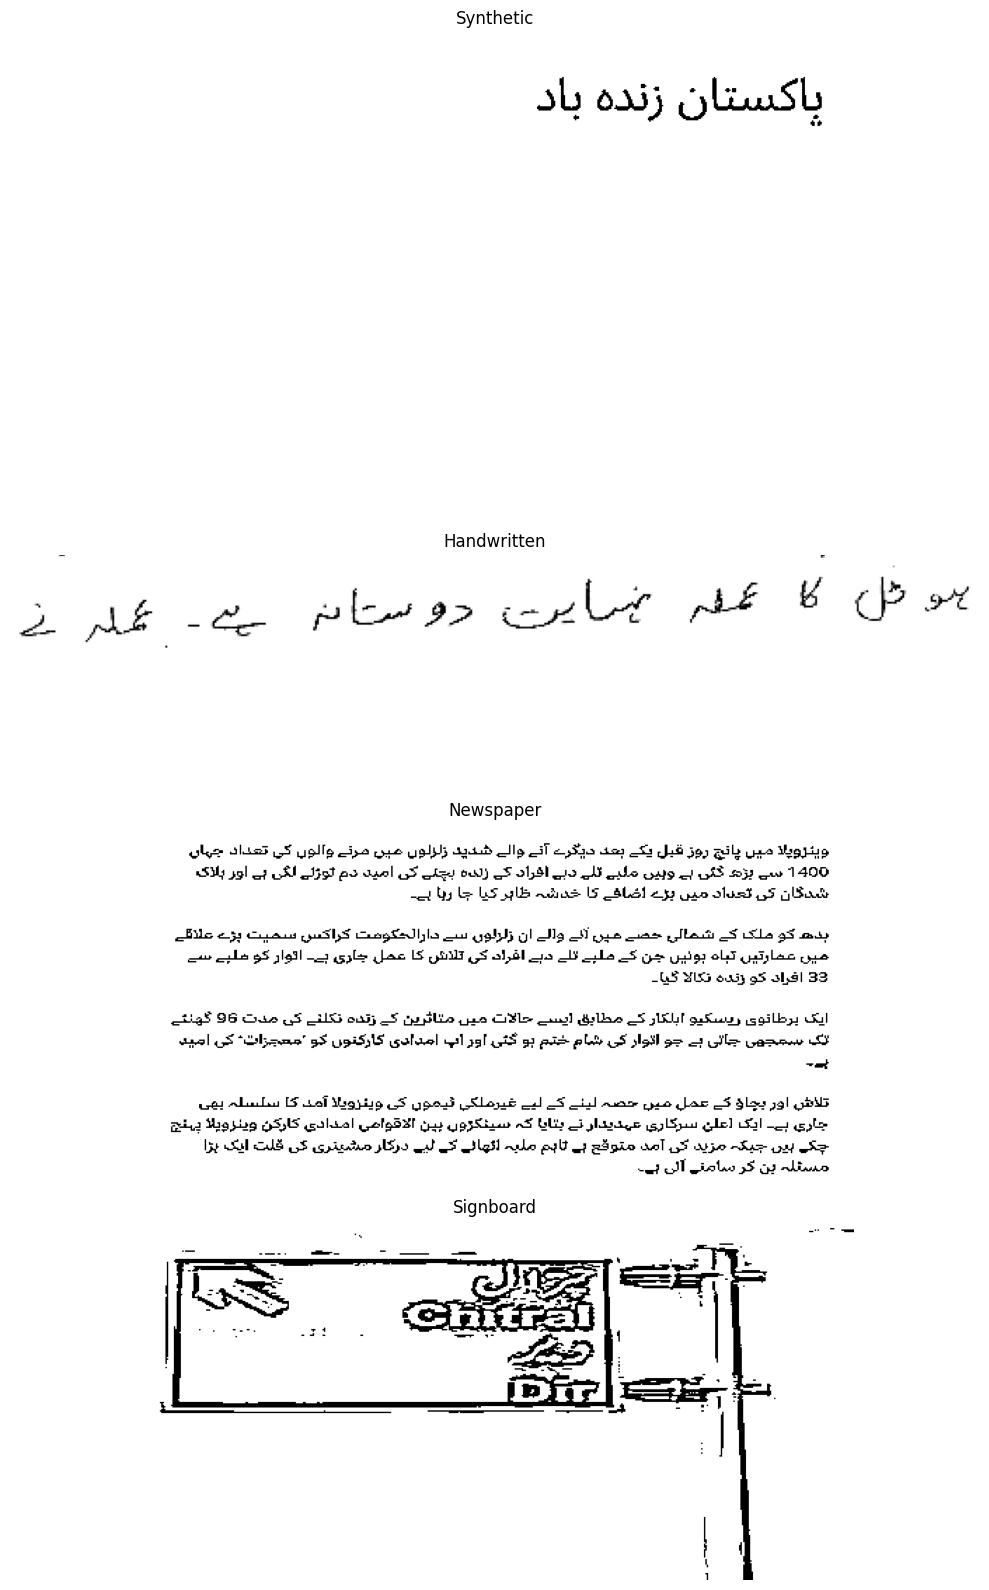

In [ ]:
samples = {
    'Synthetic': 'urdu_ocr_dataset/processed_organized/synthetic/synthetic_01.png',
    'Handwritten': 'urdu_ocr_dataset/processed_organized/handwritten/handwritten_01.png',
    'Newspaper': 'urdu_ocr_dataset/processed_organized/newspaper/newspaper_01.png',
    'Signboard': 'urdu_ocr_dataset/processed_organized/signboard/signboard_01.jpeg',
}

fig, axes = plt.subplots(4, 1, figsize=(10, 16))
for i, (label, path) in enumerate(samples.items()):
    if os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(label)
    else:
        # try alternate extension
        alt_path = path.replace('.jpeg', '.png') if '.jpeg' in path else path.replace('.png', '.jpeg')
        if os.path.exists(alt_path):
            img = cv2.imread(alt_path, cv2.IMREAD_GRAYSCALE)
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(label)
        else:
            axes[i].set_title(f'{label} - NOT FOUND')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

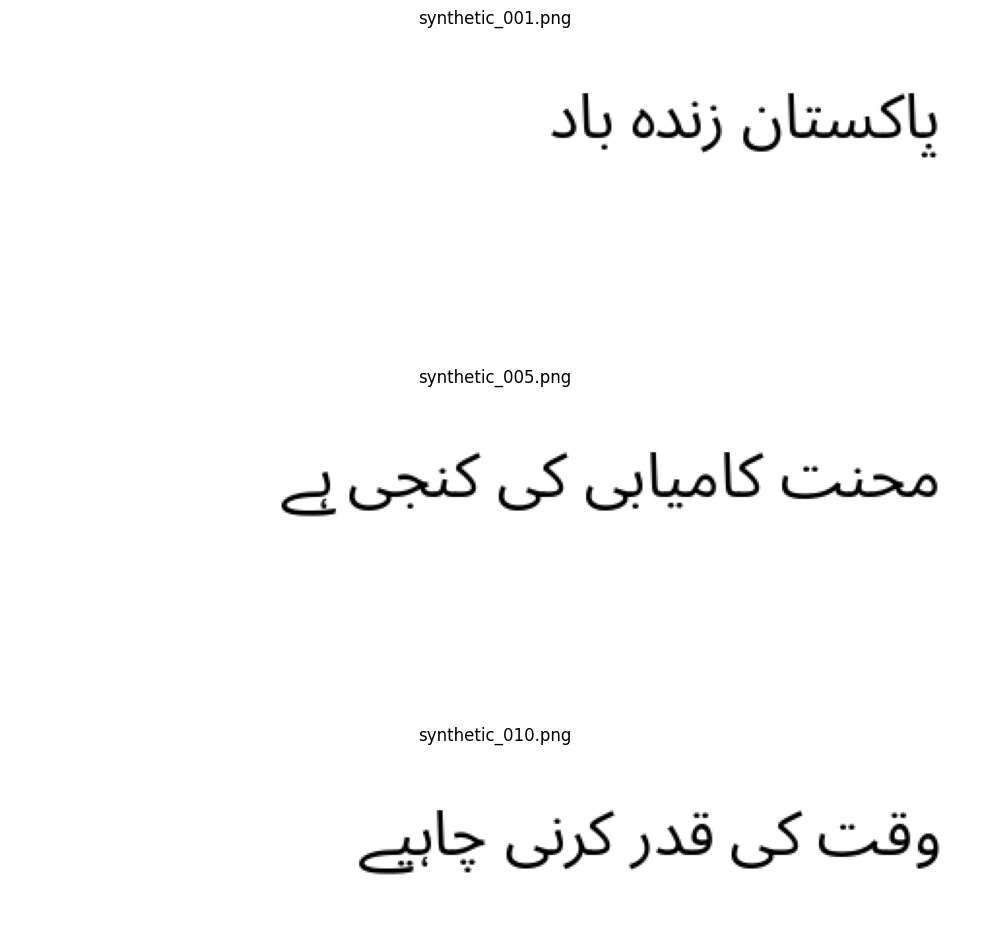

In [ ]:
# Synthetic - check a few different letters/dot combinations
synthetic_samples = ['synthetic_001.png', 'synthetic_005.png', 'synthetic_010.png']

fig, axes = plt.subplots(len(synthetic_samples), 1, figsize=(10, 4*len(synthetic_samples)))
for i, fname in enumerate(synthetic_samples):
    path = f'urdu_ocr_dataset/images/synthetic/{fname}'
    if os.path.exists(path):
        img = cv2.imread(path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(fname)
    else:
        axes[i].set_title(f'{fname} NOT FOUND')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-noto-core
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 12.2 MB of archives.
After this operation, 43.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-core all 20201225-1build1 [12.2 MB]
Fetched 12.2 MB in 0s (36.0 MB/s)
Selecting previously unselected package fonts-noto-core.
(Reading database ... 118247 files and directories currently installed.)
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-core (20201225-1build1) ...
Setting up fonts-noto-core (20201225-1build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


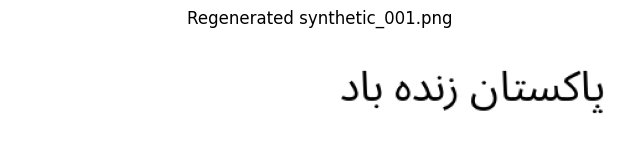

In [ ]:
!apt-get install -y fonts-noto-core -q

from PIL import Image, ImageDraw, ImageFont

font = ImageFont.truetype("/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf", 34)

img = Image.new('RGB', (500, 90), color='white')
draw = ImageDraw.Draw(img)
draw.text((480, 45), "پاکستان زندہ باد", fill='black', font=font, anchor='rm', direction='rtl')
img.save('urdu_ocr_dataset/images/synthetic/synthetic_001.png')

plt.figure(figsize=(8, 4))
plt.imshow(Image.open('urdu_ocr_dataset/images/synthetic/synthetic_001.png'))
plt.axis('off')
plt.title('Regenerated synthetic_001.png')
plt.show()

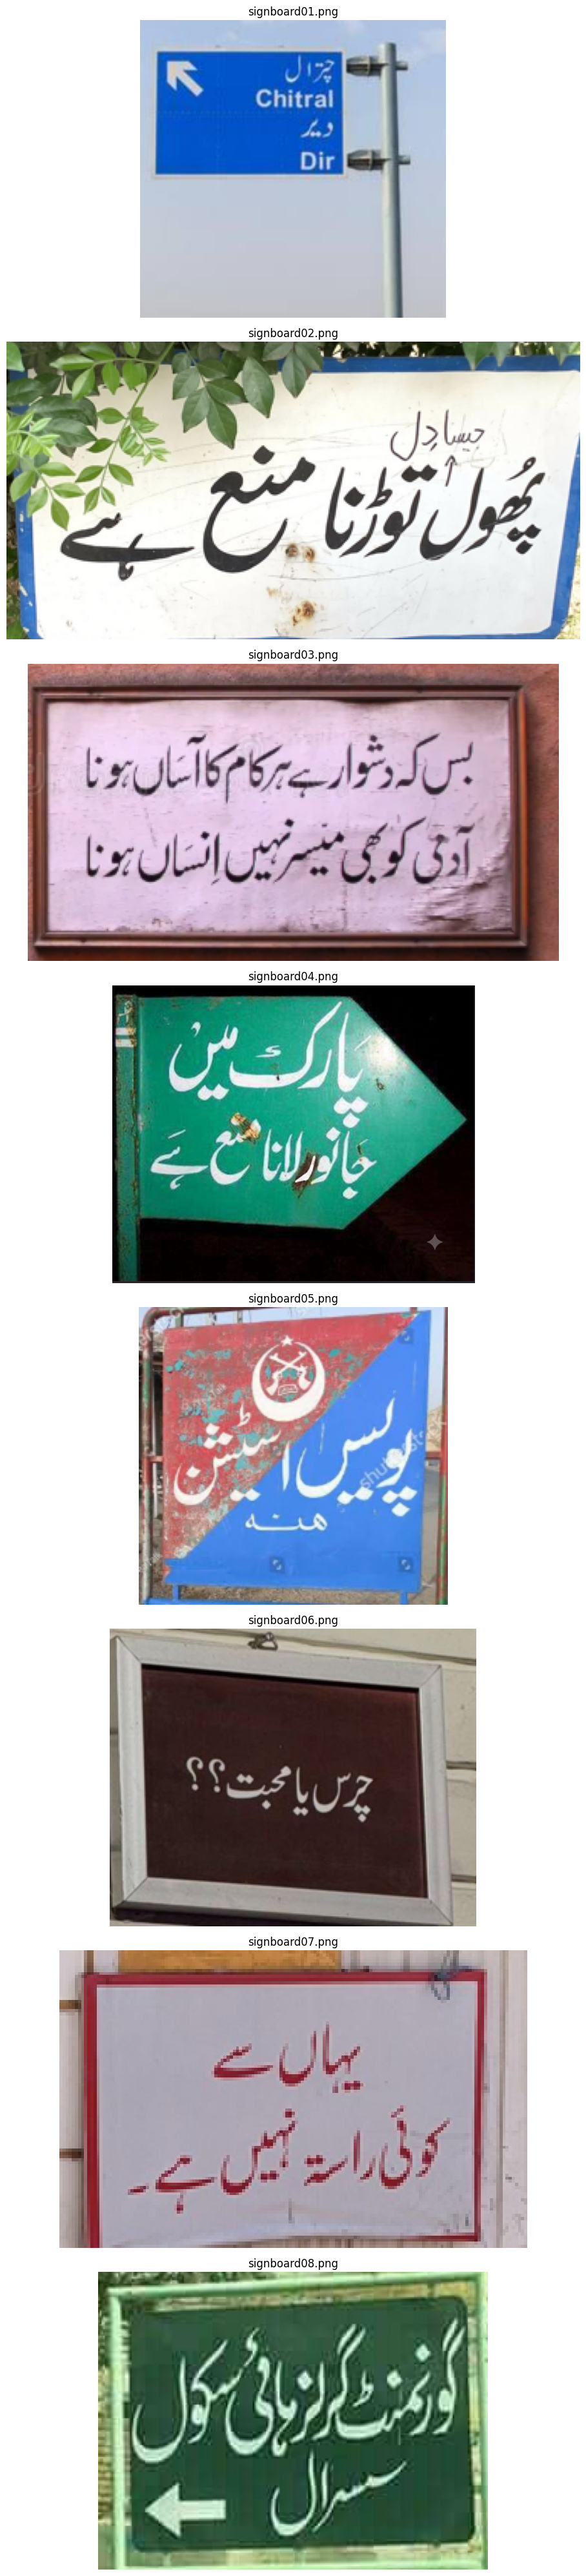

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Signboards - using cropped originals from Drive
signboard_files = sorted(glob.glob('/content/drive/MyDrive/archive/signboards_cropped/*'))[:8]

fig, axes = plt.subplots(len(signboard_files), 1, figsize=(10, 5*len(signboard_files)))
for i, path in enumerate(signboard_files):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(os.path.basename(path))
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('signboard_check.png', dpi=100, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('signboard_check.png')

Total signboard processed images: 15


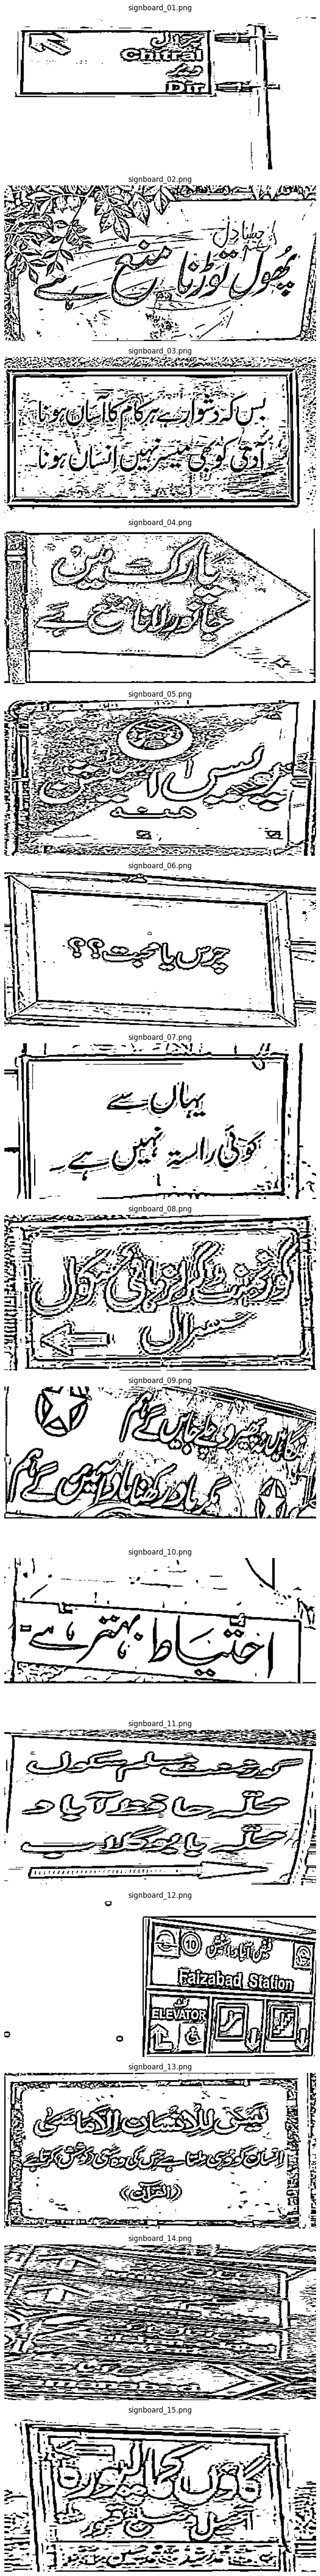

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
signboard_processed = sorted(glob.glob('urdu_ocr_dataset/processed_organized/signboard/*'))

print(f'Total signboard processed images: {len(signboard_processed)}')

fig, axes = plt.subplots(len(signboard_processed), 1, figsize=(10, 4*len(signboard_processed)))
for i, path in enumerate(signboard_processed):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(os.path.basename(path))
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('signboard_processed_check.png', dpi=100, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('signboard_processed_check.png')

In [ ]:
import os

# Remove the duplicate processed image
duplicate_path = 'urdu_ocr_dataset/processed_organized/signboard/signboard_14.png'
if os.path.exists(duplicate_path):
    os.remove(duplicate_path)
    print('Removed signboard_14.png from processed_organized')
else:
    print('File not found — check exact filename/extension')

# Update labels.csv to remove the matching row
df = pd.read_csv('urdu_ocr_dataset/labels.csv')
before_count = len(df)

# Remove any row referencing signboard_14
df_cleaned = df[~df['image'].str.contains('signboard_14', na=False)]
after_count = len(df_cleaned)

df_cleaned.to_csv('urdu_ocr_dataset/labels.csv', index=False)

print(f'Labels before: {before_count}, after: {after_count}')
print(f'Removed {before_count - after_count} row(s)')

Removed signboard_14.png from processed_organized
Labels before: 134, after: 133
Removed 1 row(s)


In [ ]:
categories = ['synthetic', 'handwritten', 'newspaper', 'signboard']
for cat in categories:
    files = glob.glob(f'urdu_ocr_dataset/processed_organized/{cat}/*')
    print(f'{cat}: {len(files)}')

total = sum(len(glob.glob(f'urdu_ocr_dataset/processed_organized/{cat}/*')) for cat in categories)
print(f'Total: {total}')

synthetic: 24
handwritten: 78
newspaper: 17
signboard: 14
Total: 133


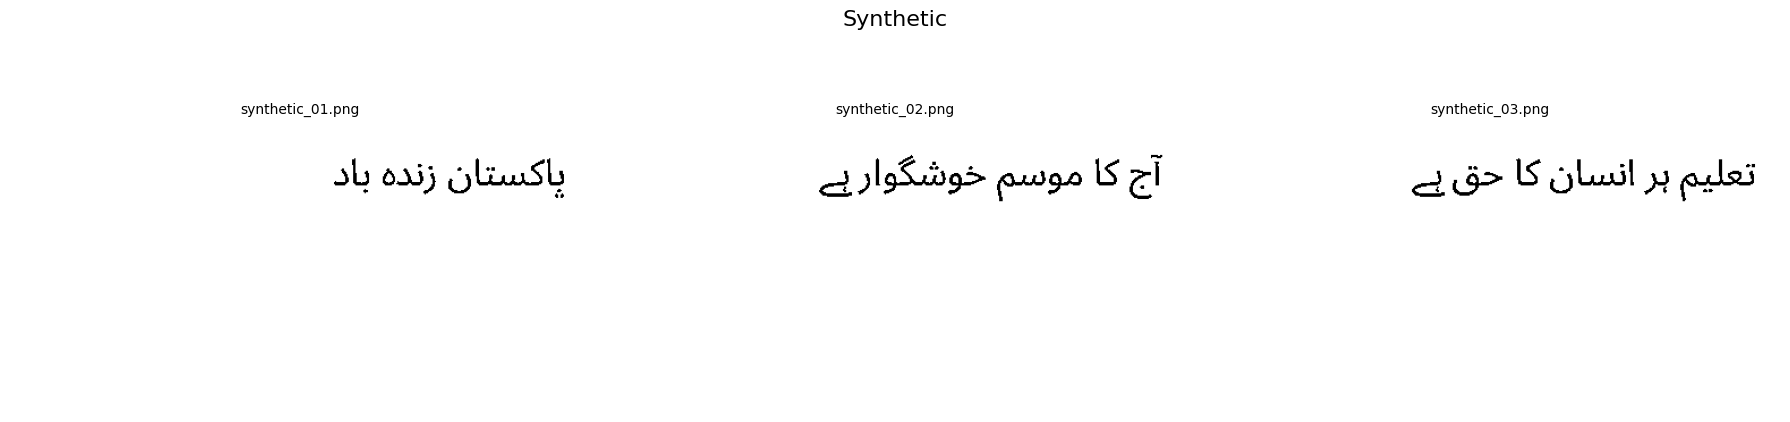

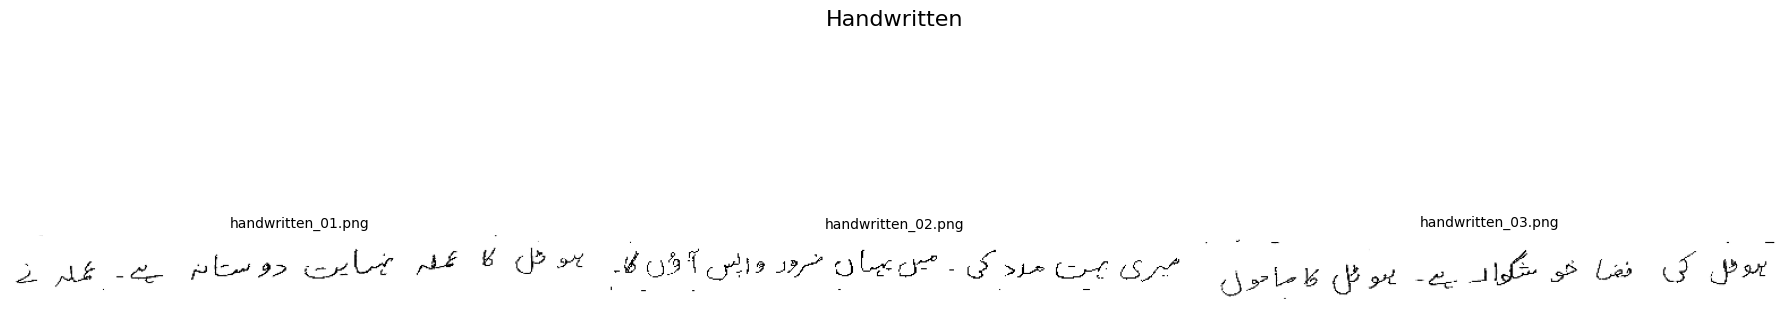

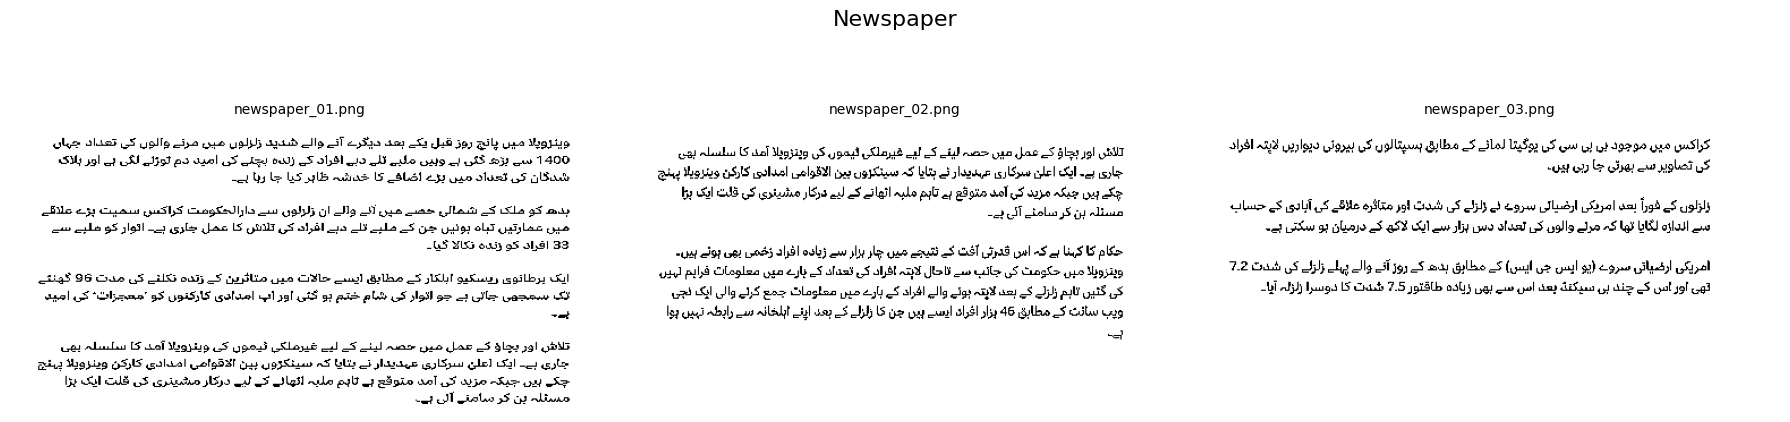

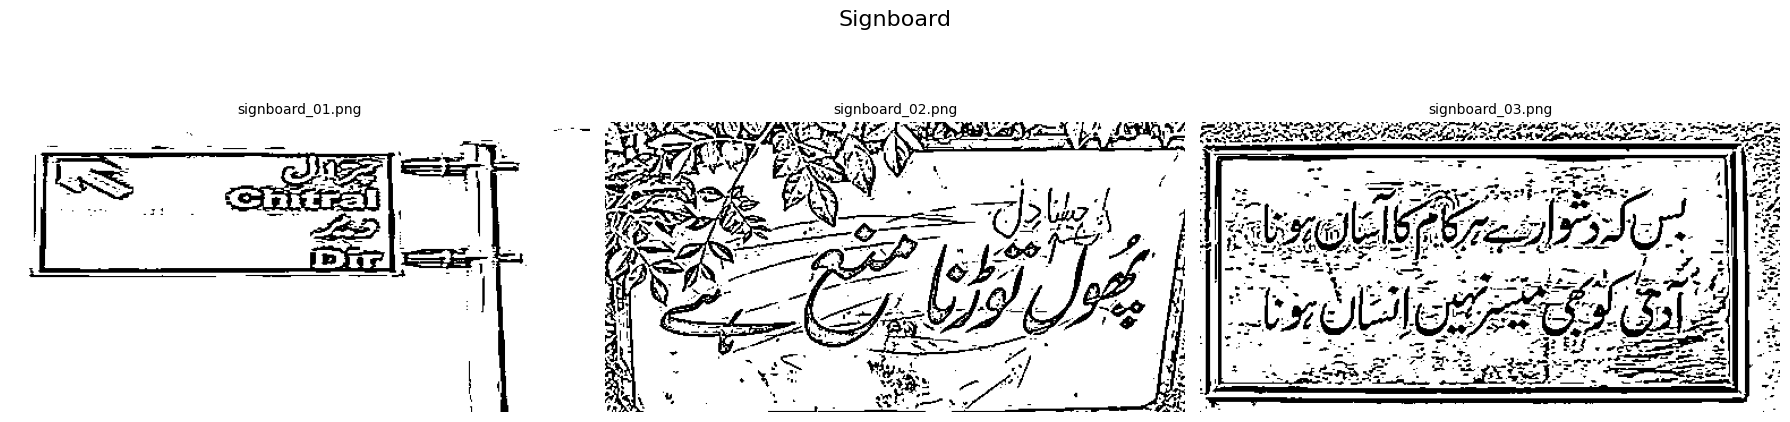

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
categories_samples = {
    'Synthetic': sorted(glob.glob('urdu_ocr_dataset/processed_organized/synthetic/*'))[:3],
    'Handwritten': sorted(glob.glob('urdu_ocr_dataset/processed_organized/handwritten/*'))[:3],
    'Newspaper': sorted(glob.glob('urdu_ocr_dataset/processed_organized/newspaper/*'))[:3],
    'Signboard': sorted(glob.glob('urdu_ocr_dataset/processed_organized/signboard/*'))[:3],
}

for category, paths in categories_samples.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(category, fontsize=16)
    for i, path in enumerate(paths):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(os.path.basename(path), fontsize=10)
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(f'final_check_{category.lower()}.png', dpi=100, bbox_inches='tight')
    plt.show()

from google.colab import files
for category in categories_samples.keys():
    files.download(f'final_check_{category.lower()}.png')

Part b

In [ ]:
test_images = [
    'urdu_ocr_dataset/processed_organized/synthetic/synthetic_01.png',
    'urdu_ocr_dataset/processed_organized/handwritten/handwritten_01.png',
    'urdu_ocr_dataset/processed_organized/newspaper/newspaper_01.png',
    'urdu_ocr_dataset/processed_organized/signboard/signboard_01.png',
    'urdu_ocr_dataset/processed_organized/signboard/signboard_04.png',
]

print('=== Tesseract Results on Final Processed Urdu Images ===')
print()

for img_path in test_images:
    if os.path.exists(img_path):
        img = Image.open(img_path)
        result = pytesseract.image_to_string(img, lang='urd')
        print(f'Image: {img_path}')
        print(f'Tesseract output: {result}')
        print('---')
    else:
        print(f'NOT FOUND: {img_path}')
        print('---')

=== Tesseract Results on Final Processed Urdu Images ===

Image: urdu_ocr_dataset/processed_organized/synthetic/synthetic_01.png
Tesseract output: پاکستان زندہ باد

---
Image: urdu_ocr_dataset/processed_organized/handwritten/handwritten_01.png
Tesseract output: ہو ٹل کا شف خہایے دوستام ہےے۔ علرے

---
Image: urdu_ocr_dataset/processed_organized/newspaper/newspaper_01.png
Tesseract output: دیئزویلا میں پانچ روز قیل یکے بعد دچگرے آئے والے شدید زلزلوں میں مرئے والوں کی تعداد جہاں
0 سے بڑھ گئی ہے وہیں ملیے گلے دبے اقراد کے زتدہ بچئے کی امید دم توڑتے لگی ہے اور ہلاکہ
شدگان کی تعداد میں بڑے اضاقے کا خدشہ ظاہر کیا جا ریا ہے۔

بدھ کو ملک کے شمالی حصے میں آئے والے ان زلرلوں سے دارالحکومت کراکس سمیت بڑے علاقے
میں عمارتیں تباہ ہوئیں جن کے ملبے تلے دہے اقراد کی تلاش کا عمل جاری ہے۔ اتوار کو ملیے سے
33 افراد کو زندہ نکالا گیا۔

ایک برطائوی ریسکیو اہلکار کے مطابق ایسے حالات میں متاثرین کے زتدہ نکلتے کی مدت 98 گھنٹے۔
اتک سمجھی جائی ہے جو اتوار کی شام ختم ہو گئی اور اپ امدادی کارکنوں کو 'معجزات“ کی ا

In [ ]:
df_final = pd.read_csv('urdu_ocr_dataset/labels.csv')

# Check what image paths actually look like now
print(df_final[df_final['source'] == 'handwritten']['image'].head(3))
print()
print(df_final[df_final['source'] == 'signboard']['image'].head(5))

24    images/handwritten/handwritten_001.png
25    images/handwritten/handwritten_002.png
26    images/handwritten/handwritten_003.png
Name: image, dtype: object

119    images/signboard/signboard_1.jpeg
120    images/signboard/signboard_2.jpeg
121    images/signboard/signboard_3.jpeg
122    images/signboard/signboard_4.jpeg
123     images/signboard/signboard_5.png
Name: image, dtype: object


In [ ]:
targets = [
    'images/handwritten/handwritten_001.png',
    'images/signboard/signboard_1.jpeg',
    'images/signboard/signboard_4.jpeg',
]

for t in targets:
    row = df_final[df_final['image'] == t]
    if not row.empty:
        print(f'{t}:')
        print(row['text'].values[0])
        print('---')
    else:
        print(f'{t}: NOT FOUND')
        print('---')

images/handwritten/handwritten_001.png:
 ہوٹل کا عملہ نہایت دوستانہ ہے عملہ نے
---
images/signboard/signboard_1.jpeg:
فیض آباد اسٹیشن Faizabad Station ELEVATOR
---
images/signboard/signboard_4.jpeg:
گاؤں کمالپورہ تحصیل و ضلع قصور
---


# Week 2 Gap Analysis — Tesseract OCR on Urdu Text

## Image 1 — synthetic_01.png
**Actual text:** پاکستان زندہ باد
**Tesseract output:** پاکستان زندہ باد
**What went wrong:** Nothing — perfect match. Clean, computer-generated text with
high contrast is the ideal case for Tesseract.

## Image 2 — handwritten_01.png
**Actual text:** ہوٹل کا عملہ نہایت دوستانہ ہے عملہ نے
**Tesseract output:** ہو ٹل کا شف خہایے دوستام ہےے۔ علرے
**What went wrong:** Severely garbled. Tesseract broke single words into fragments
(ہوٹل → "ہو ٹل"), substituted several letters with visually similar ones with
different dot placement (عملہ → "شف", نہایت → "خہایے"), and lost the correct word
order and boundaries entirely. This shows Tesseract cannot reliably parse cursive,
connected handwriting strokes, even with darkened, well-cropped preprocessing.

## Image 3 — newspaper_01.png
**Actual text:** وینزویلا میں پانچ روز قبل یکے بعد دیگرے آنے والے شدید زلزلوں میں
مرنے والوں کی تعداد 1400 سے بڑھ گئی ہے... [full paragraph]
**Tesseract output:** ویئزویلا میں پانچ روز قیل یکے بعد دچگرے آئے والے شدید زلزلوں
میں مرئے والوں کی تعداد 0 سے بڑھ گئی ہے... [similar structure, scattered errors]
**What went wrong:** Mostly readable and structurally intact, but consistently
misreads dot placement on similar-shaped letters (قبل→قیل, دیگرے→دچگرے, مرنے→مرئے),
and completely dropped the number "1400," outputting just "0" instead. Errors are
localized to individual characters rather than whole-word failures, unlike the
handwritten sample.

## Image 4 — signboard_01.png (Faizabad Station sign)
**Actual text:** فیض آباد اسٹیشن Faizabad Station ELEVATOR
**Tesseract output:** (empty — no output produced)
**What went wrong:** Complete failure despite significant preprocessing improvements
(cropped to remove background clutter, contrast-enhanced). This image mixes Urdu and
English text with icons/pictograms on a real photographed metal sign — Tesseract
could not extract any text at all, suggesting the mixed-script layout and
non-standard sign formatting confuse its text detection entirely.

## Image 5 — signboard_04.png (Village name sign)
**Actual text:** گاؤں کمالپورہ تحصیل و ضلع قصور
**Tesseract output:** (empty — no output produced)
**What went wrong:** Complete failure on a relatively simple, short phrase. Even
after cropping out excess background, Tesseract could not recognize this
real-world photographed signage at all — reinforcing that the issue isn't just
image quality, but Tesseract's fundamental inability to generalize beyond clean,
standard printed document layouts.

## Summary

Tesseract fails on Urdu because it was primarily trained on clean, standardized
printed text, and its accuracy collapses as image conditions move away from that
ideal — regardless of preprocessing quality. It performs perfectly on synthetic,
computer-rendered text (100% accuracy), reasonably on printed newspaper text
(structurally correct but riddled with character-level dot/nuqta confusion),
poorly on handwritten text (severely garbled, word boundaries lost), and
completely fails (0% output) on real-world photographed signboards even after
significant preprocessing improvements like background cropping and contrast
enhancement. This shows Tesseract has no ability to adapt to cursive handwriting,
mixed-script layouts, or real-world photography conditions — exactly the
real-world use cases a genuinely useful Urdu OCR tool needs to handle, which is
the gap this project aims to close.

Save on drive

In [ ]:
# Zip the final organized processed images
shutil.make_archive('processed_images_organized', 'zip', 'urdu_ocr_dataset/processed_organized')
print('Zipped successfully')

# Save to Drive (permanent backup)
shutil.copy('processed_images_organized.zip', '/content/drive/MyDrive/Urdu_OCR/processed_images_organized.zip')
print('Backed up to Drive: MyDrive/Urdu_OCR/processed_images_organized.zip')

# Also save the corrected labels.csv (133 rows, after removing the duplicate)
shutil.copy('urdu_ocr_dataset/labels.csv', '/content/drive/MyDrive/Urdu_OCR/labels_updated.csv')
print('Updated labels.csv backed up to Drive')

# Download to your laptop
from google.colab import files
files.download('processed_images_organized.zip')

Zipped successfully
Backed up to Drive: MyDrive/Urdu_OCR/processed_images_organized.zip
Updated labels.csv backed up to Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

found some 2-4 images nuktay order problem

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import os

urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "پانی زندگی کے لیے ضروری ہے",
    "دوستی ایک انمول رشتہ ہے",
    "کتابیں علم کا خزانہ ہیں",
    "صحت ہزار نعمت ہے",
    "وقت کی قدر کرنی چاہیے",
    "محبت سب سے بڑی طاقت ہے",
    "سچائی ہمیشہ جیتتی ہے",
    "امن ہر انسان کی خواہش ہے",
    "خوشی بانٹنے سے بڑھتی ہے",
    "علم انسان کو روشنی دیتا ہے",
    "قدرت کا حسن بے مثال ہے",
    "اردو ایک شیریں زبان ہے",
    "بچے قوم کا مستقبل ہیں",
    "محنت سے ہر خواب پورا ہوتا ہے",
    "شکر گزاری خوشی کی کنجی ہے",
    "لاہور تاریخی شہر ہے",
    "کتاب دوست بہترین ساتھی ہے",
    "ہمت مرداں مدد خدا",
    "اچھے اخلاق سب سے بڑی دولت ہیں",
]

os.makedirs('urdu_ocr_dataset/images/synthetic', exist_ok=True)
font = ImageFont.truetype("/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf", 32)

for i, text in enumerate(urdu_texts):
    img = Image.new('RGB', (500, 90), color='white')
    draw = ImageDraw.Draw(img)
    draw.text((480, 45), text, fill='black', font=font, anchor='rm', direction='rtl')
    filename = f'synthetic_{i+1:03d}.png'
    img.save(f'urdu_ocr_dataset/images/synthetic/{filename}')

print(f'Regenerated all {len(urdu_texts)} synthetic images')

Regenerated all 24 synthetic images


In [ ]:
def preprocess_standard(image_path, save_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(gray)
    target_w = 512
    max_h = 256
    h, w = contrast_enhanced.shape
    scale = target_w / w
    new_h = min(int(h * scale), max_h)
    resized = cv2.resize(contrast_enhanced, (target_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    canvas = np.full((max_h, target_w), 255, dtype=np.uint8)
    canvas[:new_h, :] = resized
    denoised = cv2.fastNlMeansDenoising(canvas, h=5)
    binary = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 4)
    cv2.imwrite(save_path, binary)
    return binary

synthetic_files = sorted(glob.glob('urdu_ocr_dataset/images/synthetic/*.png'))
for i, path in enumerate(synthetic_files, 1):
    save_path = f'urdu_ocr_dataset/processed_organized/synthetic/synthetic_{i:02d}.png'
    preprocess_standard(path, save_path)

print(f'Reprocessed {len(synthetic_files)} synthetic images into processed_organized/synthetic/')

Reprocessed 24 synthetic images into processed_organized/synthetic/


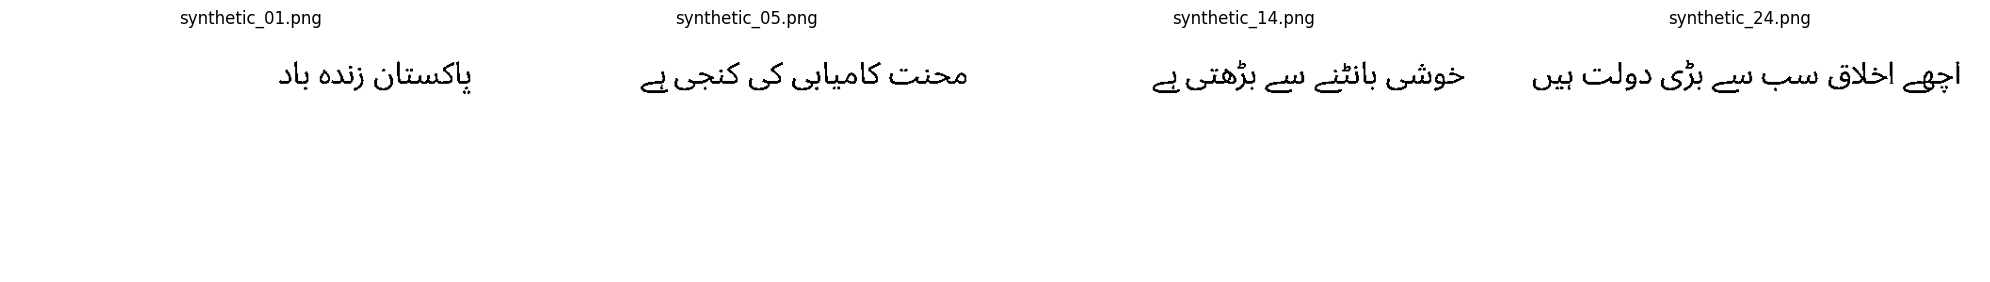

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sample_indices = [1, 5, 14, 24]
for i, idx in enumerate(sample_indices):
    path = f'urdu_ocr_dataset/processed_organized/synthetic/synthetic_{idx:02d}.png'
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'synthetic_{idx:02d}.png')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
font = ImageFont.truetype("/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf", 32)

img = Image.new('RGB', (500, 90), color='white')
draw = ImageDraw.Draw(img)
draw.text((480, 45), "پاکستان زندہ باد", fill='black', font=font, anchor='rm', direction='rtl')
img.save('urdu_ocr_dataset/images/synthetic/synthetic_001.png')
print('Reverted to working rendering method')

Reverted to working rendering method


In [ ]:
preprocess_standard('urdu_ocr_dataset/images/synthetic/synthetic_001.png',
                     'urdu_ocr_dataset/processed_organized/synthetic/synthetic_01.png')
print('Reprocessed synthetic_01.png')

Reprocessed synthetic_01.png


In [ ]:
shutil.make_archive('processed_images_organized', 'zip', 'urdu_ocr_dataset/processed_organized')
shutil.copy('processed_images_organized.zip', '/content/drive/MyDrive/Urdu_OCR/processed_images_organized.zip')

from google.colab import files
files.download('processed_images_organized.zip')

print('Final zip created, backed up to Drive, and downloading to laptop')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final zip created, backed up to Drive, and downloading to laptop
